In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
imdb_df = pd.read_csv("imdb.csv")
imdb_df.head()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,"107,163","Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
1,The Guilty,2021,6.3,"64,375","Crime, Drama, Thriller",90.0,Film,R,-,NaN,NaN,Severe,NaN,Moderate
2,The Many Saints of Newark,2021,6.4,"27,145","Crime, Drama",120.0,Film,R,-,Moderate,Severe,Severe,Moderate,Moderate
3,Venom: Let There Be Carnage,2021,6.4,"30,443","Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,NaN,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,"84,636","Action, Adventure, Drama",155.0,Film,PG-13,-,NaN,Moderate,NaN,Mild,Moderate


In [31]:
imdb_df.tail()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
6173,The Human Centipede II (Full Sequence),2011,3.8,"37,492",Horror,91.0,Film,Not Rated,-,Severe,Severe,Severe,Mild,Severe
6174,Double Indemnity,1944,8.3,"150,448","Crime, Drama, Film-Noir",107.0,Film,Passed,-,NaN,Mild,NaN,Mild,Mild
6175,Before the Devil Knows You're Dead,2007,7.3,"100,668","Crime, Drama, Thriller",117.0,Film,R,-,Severe,Moderate,Severe,Severe,Severe
6176,Queen Bees,2021,6.0,887,"Comedy, Drama, Romance",100.0,Film,PG-13,-,NaN,NaN,Mild,Moderate,NaN
6177,Death Race,2008,6.3,"203,578","Action, Sci-Fi, Thriller",105.0,Film,R,-,Mild,Severe,Severe,Mild,Moderate


## Data PreProcessing

In [32]:
imdb_df.shape

(6178, 14)

In [33]:
imdb_df.columns

Index(['Name', 'Date', 'Rate', 'Votes', 'Genre', 'Duration', 'Type',
       'Certificate', 'Episodes', 'Nudity', 'Violence', 'Profanity', 'Alcohol',
       'Frightening'],
      dtype='object')

In [34]:
imdb_df.sample(10)

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
4890,Doctor Doctor,2007,7.8,"2,563","Comedy, Drama",50.0,Series,Not Rated,48,Moderate,Moderate,Moderate,Moderate,Moderate
4036,Rudy,1993,7.5,"60,323","Biography, Drama, Sport",114.0,Film,PG,-,NaN,Mild,Moderate,Mild,Mild
662,The Last of Us,1987,No Rate,No Votes,"Action, Adventure, Drama",NaN,Series,NaN,6,No Rate,No Rate,No Rate,No Rate,No Rate
5317,Observe and Report,2009,5.8,"62,197","Comedy, Crime, Drama",86.0,Film,R,-,Severe,Moderate,Severe,Severe,Mild
1861,Valerian and the City of a Thousand Planets,2017,6.5,"171,779","Action, Adventure, Fantasy",136.0,Film,PG-13,-,Mild,Mild,Mild,NaN,Mild
1900,Hightown,2018,6.5,"2,930","Crime, Drama, Mystery",60.0,Series,TV-MA,18,Severe,Moderate,Severe,Severe,Mild
103,Star Wars: Visions,2021,7.2,"9,175","Animation, Action, Adventure",NaN,Series,TV-PG,9,NaN,Mild,NaN,No Rate,Mild
2393,Before I Wake,2016,6.2,"43,533","Drama, Fantasy, Horror",97.0,Film,PG-13,-,NaN,Mild,NaN,Mild,Moderate
1036,Luna Park,2022,6.4,278,"Drama, Romance",NaN,Series,TV-MA,6,No Rate,No Rate,No Rate,No Rate,No Rate
1554,Hustle,2022,No Rate,No Votes,"Comedy, Drama, Sport",NaN,Film,NaN,-,No Rate,No Rate,No Rate,No Rate,No Rate


In [35]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6178 entries, 0 to 6177
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         6178 non-null   object 
 1   Date         6178 non-null   int64  
 2   Rate         6178 non-null   object 
 3   Votes        6178 non-null   object 
 4   Genre        6178 non-null   object 
 5   Duration     5877 non-null   float64
 6   Type         6178 non-null   object 
 7   Certificate  5728 non-null   object 
 8   Episodes     6178 non-null   object 
 9   Nudity       4719 non-null   object 
 10  Violence     5504 non-null   object 
 11  Profanity    5520 non-null   object 
 12  Alcohol      5407 non-null   object 
 13  Frightening  5320 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 675.8+ KB


In [36]:
imdb_df.isnull().sum()

Name              0
Date              0
Rate              0
Votes             0
Genre             0
Duration        301
Type              0
Certificate     450
Episodes          0
Nudity         1459
Violence        674
Profanity       658
Alcohol         771
Frightening     858
dtype: int64

In [37]:
imdb_df.describe()

,Date,Duration
count,6178.000000,5877.000000
mean,2005.952574,94.576995
std,15.910248,41.765795
min,1922.000000,2.000000
25%,1998.000000,70.000000
50%,2011.000000,100.000000
75%,2019.000000,116.000000
max,2023.000000,900.000000


In [38]:
imdb_df.describe(include='object')

,Name,Rate,Votes,Genre,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
count,6178,6178,6178,6178,6178,5728,6178,4719,5504,5520,5407,5320
unique,4820,77,4802,377,2,22,284,4,4,4,4,4
top,King Kong,7.3,No Votes,Comedy,Film,R,-,Mild,Moderate,Mild,Mild,Moderate
freq,5,273,185,268,4446,1885,4446,2292,1814,2077,3257,1969


In [39]:
sel_col = imdb_df[['Name', 'Rate','Votes']]
sel_col.head()

,Name,Rate,Votes
0,No Time to Die,7.6,"107,163"
1,The Guilty,6.3,"64,375"
2,The Many Saints of Newark,6.4,"27,145"
3,Venom: Let There Be Carnage,6.4,"30,443"
4,Dune,8.3,"84,636"


In [40]:
KK_data = imdb_df.loc[imdb_df.Name=='King Kong']
KK_data

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
2084,King Kong,2005,7.2,"407,876","Action, Adventure, Drama",187.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
4207,King Kong,1976,5.9,"31,536","Adventure, Horror",134.0,Film,PG,-,Mild,Moderate,Mild,Mild,Moderate
4951,King Kong,1933,7.9,"82,705","Adventure, Horror, Sci-Fi",100.0,Film,Passed,-,Mild,Moderate,NaN,Mild,Moderate
5357,King Kong,1976,5.9,"31,536","Adventure, Horror",134.0,Film,PG,-,Mild,Moderate,Mild,Mild,Moderate
6101,King Kong,1933,7.9,"82,705","Adventure, Horror, Sci-Fi",100.0,Film,Passed,-,Mild,Moderate,NaN,Mild,Moderate


In [41]:
imdb_df = imdb_df.drop_duplicates()
imdb_df.shape

(5028, 14)

In [42]:
KK_data = imdb_df.loc[imdb_df.Name=='King Kong']
KK_data

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
2084,King Kong,2005,7.2,"407,876","Action, Adventure, Drama",187.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
4207,King Kong,1976,5.9,"31,536","Adventure, Horror",134.0,Film,PG,-,Mild,Moderate,Mild,Mild,Moderate
4951,King Kong,1933,7.9,"82,705","Adventure, Horror, Sci-Fi",100.0,Film,Passed,-,Mild,Moderate,NaN,Mild,Moderate


In [43]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5028 entries, 0 to 5027
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         5028 non-null   object 
 1   Date         5028 non-null   int64  
 2   Rate         5028 non-null   object 
 3   Votes        5028 non-null   object 
 4   Genre        5028 non-null   object 
 5   Duration     4780 non-null   float64
 6   Type         5028 non-null   object 
 7   Certificate  4684 non-null   object 
 8   Episodes     5028 non-null   object 
 9   Nudity       3846 non-null   object 
 10  Violence     4497 non-null   object 
 11  Profanity    4504 non-null   object 
 12  Alcohol      4414 non-null   object 
 13  Frightening  4358 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 589.2+ KB


In [44]:
imdb_df.head()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,"107,163","Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
1,The Guilty,2021,6.3,"64,375","Crime, Drama, Thriller",90.0,Film,R,-,NaN,NaN,Severe,NaN,Moderate
2,The Many Saints of Newark,2021,6.4,"27,145","Crime, Drama",120.0,Film,R,-,Moderate,Severe,Severe,Moderate,Moderate
3,Venom: Let There Be Carnage,2021,6.4,"30,443","Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,NaN,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,"84,636","Action, Adventure, Drama",155.0,Film,PG-13,-,NaN,Moderate,NaN,Mild,Moderate


In [45]:
imdb_df.shape[0]

5028

In [46]:
for i in range(0, imdb_df.shape[0]):
    imdb_df['Votes'][i] = imdb_df['Votes'][i].replace(',','')

imdb_df['Votes']
    

0       107163
1        64375
2        27145
3        30443
4        84636
         ...  
5023     37492
5024    150448
5025    100668
5026       887
5027    203578
Name: Votes, Length: 5028, dtype: object

In [53]:
imdb_df['Rate'] = pd.to_numeric(imdb_df['Rate'], errors='coerce')

In [54]:
imdb_df['Votes'] = pd.to_numeric(imdb_df['Votes'], errors='coerce')

In [55]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5028 entries, 0 to 5027
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         5028 non-null   object 
 1   Date         5028 non-null   int64  
 2   Rate         4875 non-null   float64
 3   Votes        4875 non-null   float64
 4   Genre        5028 non-null   object 
 5   Duration     4780 non-null   float64
 6   Type         5028 non-null   object 
 7   Certificate  4684 non-null   object 
 8   Episodes     5028 non-null   object 
 9   Nudity       3846 non-null   object 
 10  Violence     4497 non-null   object 
 11  Profanity    4504 non-null   object 
 12  Alcohol      4414 non-null   object 
 13  Frightening  4358 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 718.3+ KB


In [56]:
imdb_df.describe()

,Date,Rate,Votes,Duration
count,5028.000000,4875.000000,4.875000e+03,4780.000000
mean,2006.159905,6.929764,1.369032e+05,94.685356
std,15.789378,1.070860,2.087452e+05,42.127391
min,1922.000000,1.200000,3.100000e+01,2.000000
25%,1998.000000,6.300000,1.605450e+04,60.000000
50%,2011.000000,7.000000,6.485700e+04,100.000000
75%,2019.000000,7.700000,1.724660e+05,117.000000
max,2023.000000,9.700000,2.474122e+06,900.000000


In [57]:
imdb_df.isnull().sum()

Name              0
Date              0
Rate            153
Votes           153
Genre             0
Duration        248
Type              0
Certificate     344
Episodes          0
Nudity         1182
Violence        531
Profanity       524
Alcohol         614
Frightening     670
dtype: int64

In [60]:
imdb_df['Rate'] = imdb_df['Rate'].replace(np.nan, 0)
imdb_df['Votes'] = imdb_df["Votes"].replace(np.nan, 0)
imdb_df['Duration'] = imdb_df['Duration'].replace(np.nan, 0)

In [61]:
imdb_df.isnull().sum()

Name              0
Date              0
Rate              0
Votes             0
Genre             0
Duration          0
Type              0
Certificate     344
Episodes          0
Nudity         1182
Violence        531
Profanity       524
Alcohol         614
Frightening     670
dtype: int64

In [62]:
imdb_df = imdb_df.replace(np.nan, 'None')

In [63]:
imdb_df.isnull().sum()

Name           0
Date           0
Rate           0
Votes          0
Genre          0
Duration       0
Type           0
Certificate    0
Episodes       0
Nudity         0
Violence       0
Profanity      0
Alcohol        0
Frightening    0
dtype: int64

In [64]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5028 entries, 0 to 5027
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         5028 non-null   object 
 1   Date         5028 non-null   int64  
 2   Rate         5028 non-null   float64
 3   Votes        5028 non-null   float64
 4   Genre        5028 non-null   object 
 5   Duration     5028 non-null   float64
 6   Type         5028 non-null   object 
 7   Certificate  5028 non-null   object 
 8   Episodes     5028 non-null   object 
 9   Nudity       5028 non-null   object 
 10  Violence     5028 non-null   object 
 11  Profanity    5028 non-null   object 
 12  Alcohol      5028 non-null   object 
 13  Frightening  5028 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 718.3+ KB


## Data Visualization

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

%matplotlib inline

sns.set_style("whitegrid")

<Axes: xlabel='Rate', ylabel='Count'>

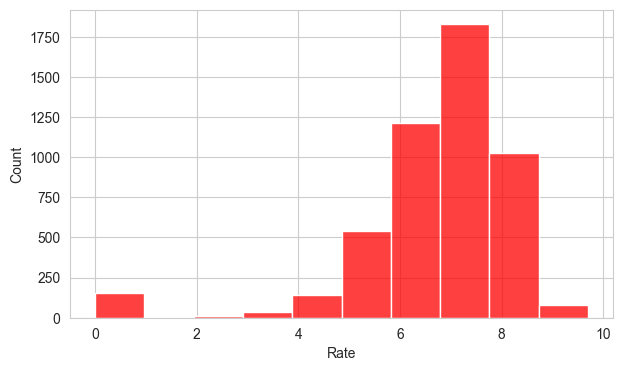

In [72]:
plt.figure(figsize=(7,4))

sns.histplot(x="Rate", data=imdb_df, color="red", binwidth=1)

In [73]:
imdb_df.head()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,107163.0,"Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
1,The Guilty,2021,6.3,64375.0,"Crime, Drama, Thriller",90.0,Film,R,-,None,None,Severe,None,Moderate
2,The Many Saints of Newark,2021,6.4,27145.0,"Crime, Drama",120.0,Film,R,-,Moderate,Severe,Severe,Moderate,Moderate
3,Venom: Let There Be Carnage,2021,6.4,30443.0,"Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,None,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,84636.0,"Action, Adventure, Drama",155.0,Film,PG-13,-,None,Moderate,None,Mild,Moderate


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'PG-13'),
  Text(1, 0, 'R'),
  Text(2, 0, 'TV-MA'),
  Text(3, 0, 'None'),
  Text(4, 0, 'TV-14'),
  Text(5, 0, 'TV-PG'),
  Text(6, 0, 'PG'),
  Text(7, 0, 'TV-G'),
  Text(8, 0, '(Banned)'),
  Text(9, 0, 'Not Rated'),
  Text(10, 0, 'E'),
  Text(11, 0, 'NC-17'),
  Text(12, 0, 'TV-Y7-FV'),
  Text(13, 0, 'TV-Y7'),
  Text(14, 0, 'Unrated'),
  Text(15, 0, 'Approved'),
  Text(16, 0, 'G'),
  Text(17, 0, 'TV-Y'),
  Text(18, 0, 'GP'),
  Text(19, 0, 'Passed'),
  Text(20, 0, 'M'),
  Text(21, 0, 'X'),
  Text(22, 0, 'M/PG')])

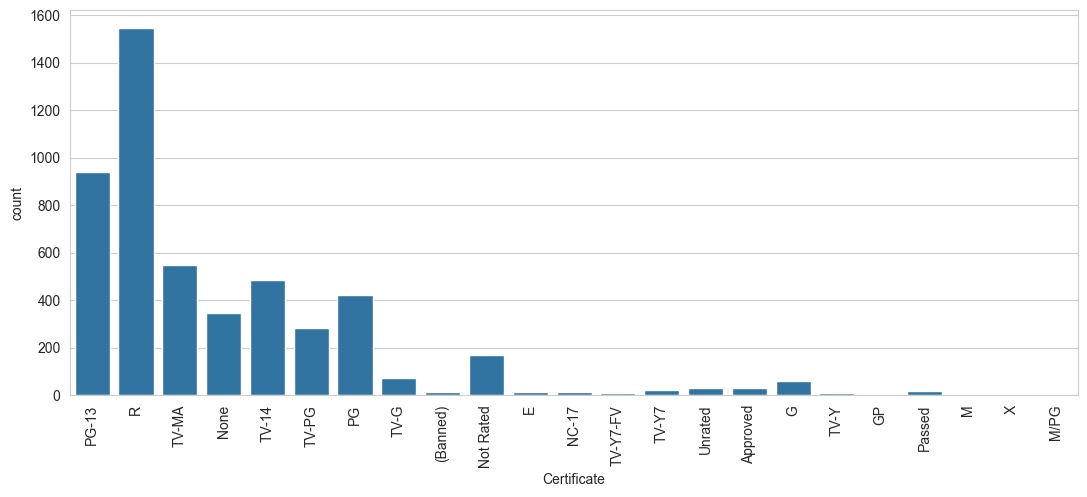

In [77]:
plt.figure(figsize=(13,5))

sns.countplot(x='Certificate', data=imdb_df)
plt.xticks(rotation=90)

In [78]:
imdb_df.head()


,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,107163.0,"Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
1,The Guilty,2021,6.3,64375.0,"Crime, Drama, Thriller",90.0,Film,R,-,None,None,Severe,None,Moderate
2,The Many Saints of Newark,2021,6.4,27145.0,"Crime, Drama",120.0,Film,R,-,Moderate,Severe,Severe,Moderate,Moderate
3,Venom: Let There Be Carnage,2021,6.4,30443.0,"Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,None,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,84636.0,"Action, Adventure, Drama",155.0,Film,PG-13,-,None,Moderate,None,Mild,Moderate


In [79]:
PG13_data = imdb_df.loc[imdb_df.Certificate == 'PG-13']
PG13_data.head()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,107163.0,"Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
3,Venom: Let There Be Carnage,2021,6.4,30443.0,"Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,None,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,84636.0,"Action, Adventure, Drama",155.0,Film,PG-13,-,None,Moderate,None,Mild,Moderate
6,Free Guy,2021,7.3,153835.0,"Action, Adventure, Comedy",115.0,Film,PG-13,-,Mild,Moderate,Moderate,None,Mild
19,Black Widow,2021,6.8,246603.0,"Action, Adventure, Sci-Fi",134.0,Film,PG-13,-,None,Moderate,Mild,Mild,Moderate


<Axes: xlabel='Rate', ylabel='Density'>

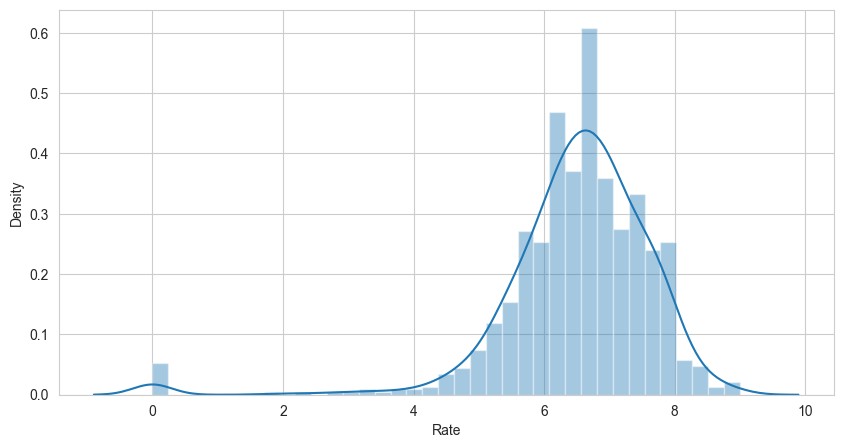

In [81]:
plt.figure(figsize=(10,5))

sns.distplot(PG13_data['Rate'])

<Axes: xlabel='Rate', ylabel='Votes'>

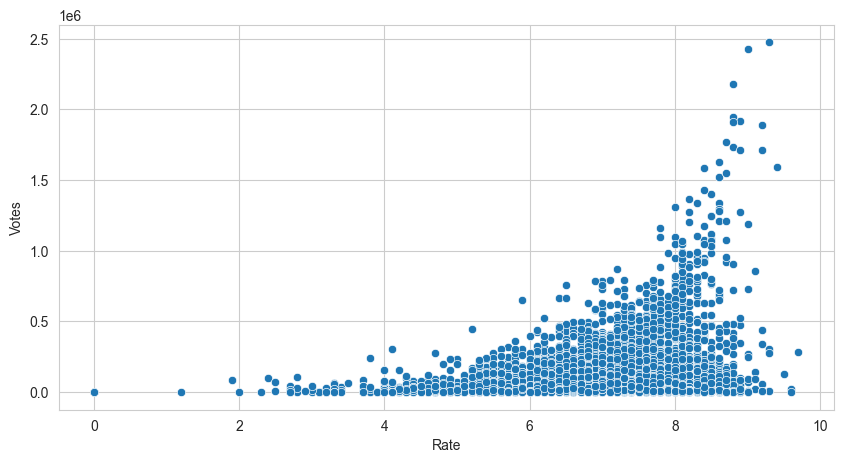

In [82]:
plt.figure(figsize=(10,5))

sns.scatterplot(x='Rate', y='Votes', data=imdb_df)

In [83]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5028 entries, 0 to 5027
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         5028 non-null   object 
 1   Date         5028 non-null   int64  
 2   Rate         5028 non-null   float64
 3   Votes        5028 non-null   float64
 4   Genre        5028 non-null   object 
 5   Duration     5028 non-null   float64
 6   Type         5028 non-null   object 
 7   Certificate  5028 non-null   object 
 8   Episodes     5028 non-null   object 
 9   Nudity       5028 non-null   object 
 10  Violence     5028 non-null   object 
 11  Profanity    5028 non-null   object 
 12  Alcohol      5028 non-null   object 
 13  Frightening  5028 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 718.3+ KB


In [84]:
num_fea = imdb_df[['Rate', 'Votes', 'Duration']]
num_fea.head()

,Rate,Votes,Duration
0,7.6,107163.0,163.0
1,6.3,64375.0,90.0
2,6.4,27145.0,120.0
3,6.4,30443.0,97.0
4,8.3,84636.0,155.0


In [85]:
corr = num_fea.corr()
corr

,Rate,Votes,Duration
Rate,1.000000,0.283042,0.136943
Votes,0.283042,1.000000,0.321123
Duration,0.136943,0.321123,1.000000


<Axes: >

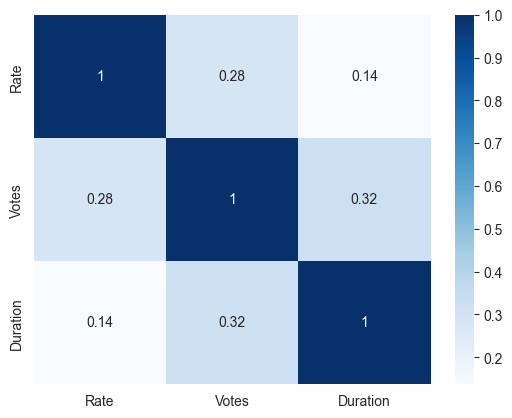

In [87]:
sns.heatmap(corr, annot=True,cmap="Blues")

In [88]:
top_rated = imdb_df.nlargest(10, 'Rate')
top_rated

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
1946,Aspirants,2004,9.7,286206.0,Drama,45.0,Series,None,5,No Rate,No Rate,No Rate,No Rate,No Rate
909,The Chosen,2007,9.6,21759.0,"Drama, History",54.0,Series,TV-PG,17,None,None,None,None,Mild
1754,Bluey,2005,9.6,4110.0,"Animation, Family",7.0,Series,TV-Y,147,None,None,None,None,None
2780,Scam 1992: The Harshad Mehta Story,2020,9.5,131914.0,"Biography, Crime, Drama",54.0,Series,TV-14,10,None,None,Mild,Mild,None
52,Breaking Bad,2021,9.4,1593305.0,"Crime, Drama, Thriller",49.0,Series,TV-MA,62,Mild,Severe,Moderate,Severe,Severe
109,The Wire,2021,9.3,306334.0,"Crime, Drama, Thriller",59.0,Series,TV-MA,60,Severe,Severe,Severe,Severe,Severe
201,The Shawshank Redemption,1994,9.3,2474122.0,Drama,142.0,Film,R,-,Mild,Moderate,Severe,Mild,Moderate
500,Avatar: The Last Airbender,1974,9.3,273781.0,"Animation, Action, Adventure",23.0,Series,TV-Y7-FV,62,None,Mild,None,None,Moderate
819,Toma,2021,9.3,5562.0,"Biography, Drama, Music",140.0,Film,None,-,No Rate,No Rate,No Rate,No Rate,No Rate
13,The Sopranos,2021,9.2,340006.0,"Crime, Drama",55.0,Series,TV-MA,86,Severe,Severe,Severe,Severe,Severe


<Axes: xlabel='Type', ylabel='count'>

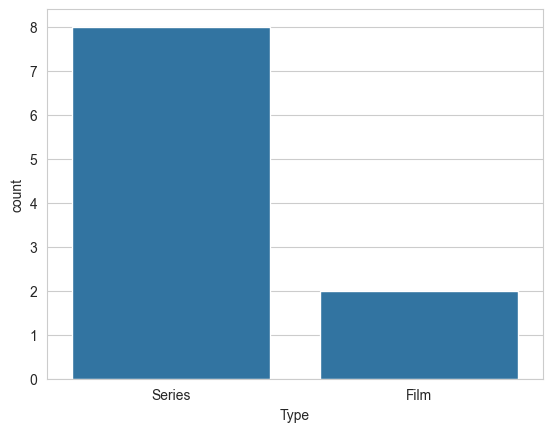

In [89]:
sns.countplot(x='Type', data = top_rated)

In [90]:
top_rated.loc[top_rated.Type == 'Series']['Name']

1946                             Aspirants
909                             The Chosen
1754                                 Bluey
2780    Scam 1992: The Harshad Mehta Story
52                            Breaking Bad
109                               The Wire
500             Avatar: The Last Airbender
13                            The Sopranos
Name: Name, dtype: object

In [93]:
top_rated.loc[top_rated.Type == 'Film']['Name']

201    The Shawshank Redemption
819                        Toma
Name: Name, dtype: object